# Does inverting the DAPI image sharpen its stitching registration?

`test_stitching.ipynb`'s real run on `BC555_sample_05` found beads register
more precisely than DAPI (near-zero diagonal loop-closure residual for
beads vs. a systematically higher one for DAPI, in every corner of every
neighbourhood) -- attributed to beads being sharp, localized point sources,
while DAPI's nuclear signal is broad/diffuse, so phase correlation responds
more weakly to a small true position error.

**Hypothesis under test** (the user's): invert the DAPI image
(`2**16 - I`) and remove its new minimum so the background sits near zero.
Nuclei (the raw image's bright blobs) become the new *background*; the
inter-nuclear gaps (raw background) become the new bright regions. If those
gaps are thin/sharp relative to the smooth nuclear blobs, the inverted
image's dominant spatial content might resemble beads' point-like sharpness
more than DAPI's own diffuse blobs.

**A caveat worth stating up front, not discovering by surprise from a null
result**: this repo's registration primitive is
`skimage.registration.phase_cross_correlation` (`alignment.phase_drift`),
a *normalized* cross-power-spectrum method, and `overlap_correlation`'s
own quality score is a Pearson correlation. Both are, in the noiseless
case, invariant (up to an irrelevant sign flip) to a purely affine
transform of one image's intensities -- `2**16 - I` followed by an
additive shift is exactly that, so in principle it should not change
registration at all. The one real, non-affine step in the actual pipeline
is `alignment.remove_hot_pixels` (called inside both `phase_drift` and
`overlap_correlation`): its hot-pixel test is `img > ratio * local_median`,
a *multiplicative* threshold, so it responds differently depending on
where the background sits relative to zero -- which is exactly what the
"remove the minimum value" step changes. So any real effect found here is
most likely mediated by that hot-pixel step, not by phase correlation
itself becoming "sharper" in some fundamental sense -- worth keeping in
mind when interpreting the plots below.

**Two tests, both on `BC555_sample_05/epi` (real data, `cells`-round
frames only -- beads = frame 0, DAPI = 405nm z-index 3, both real HAL
conventions this repo already relies on elsewhere)**:

1. **Mechanistic** (Section 5): on a handful of real overlapping tile
   pairs, apply small known synthetic sub-pixel shifts and plot Pearson
   correlation vs. shift for beads / raw DAPI / inverted DAPI -- directly
   visualizes whether inversion sharpens (narrows) the correlation
   response near the true alignment, the specific mechanism the
   hypothesis describes.
2. **Practical** (Section 7): re-run `camera_rotation.
   sample_neighbor_correspondences` (the same primitive `test_stitching.
   ipynb`/`compare_stitching_correction_methods.ipynb` use for real
   4-connected-edge registration) over a real sample of the grid, for all
   three channels, and compare the distribution of `phase_cross_correlation`'s
   own registration error -- the bottom-line "does this actually help
   real stitching" question.

Follows `NOTEBOOK_GUIDELINES.md`: calculation cells cached under
`analysis/cache/test_dapi_inversion/`, skip recomputation when a valid
cache exists, `ProgressReporter` progress, explicit plot font sizes, every
displayed figure also saved to `analysis/figures/`.

## 1 — Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import shift as ndi_shift

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/tests/stitching/test_stitching.ipynb.
MERCI_DIR = Path(os.getcwd()).parent.parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import load_positions, read_image_frames
from MERci.common.experiment_info import load_experiment_info, resolve_sample_identity, positions_file_tag
from MERci.acquisition.configs    import (
    find_frame_table_for_hal_config, get_camera_pixel_size_um, get_camera_frame_size,
    get_all_color_frame_indices,
)
from MERci.acquisition.positions       import find_grid_neighbor
from MERci.acquisition.camera_rotation import (
    apply_microscope_orientation, crop_overlap, sample_neighbor_correspondences, NeighborCorrespondence,
)
from MERci.acquisition.alignment  import remove_hot_pixels, phase_drift
from MERci.acquisition.merlin_config import load_microscope_orientation
from MERci.progress_display       import ProgressReporter

NOTEBOOK_NAME = "test_dapi_inversion"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci


## 2 — Parameters

In [2]:
# Same real dataset test_stitching.ipynb already established a beads-vs-DAPI
# residual gap on -- lets this notebook's result be compared directly against
# that known baseline rather than a fresh, uncalibrated one.
SAMPLE_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi")
IMAGE_SUFFIX = ".zarr"

BEAD_FRAME_INDEX = 0     # HAL's own bead/fiducial frame convention (cells round)
DAPI_COLOR_NM    = 405.0
DAPI_Z_INDEX     = 3     # same z-index test_stitching.ipynb uses

CHANNELS = ("beads", "dapi_raw", "dapi_inv")

TOLERANCE_FRACTION = 0.25   # same default as find_grid_neighbor
UPSAMPLE_FACTOR     = 10    # sub-pixel registration precision (1/UPSAMPLE_FACTOR px)
SEED = 0

# Section 5 (mechanistic): how many real edges to sample, and the synthetic
# sub-pixel shift sweep (applied along the overlap's own short axis, i.e. the
# axis a small position error would actually move the neighbour along).
N_EDGES_FOR_SHIFT_CURVE = 8
SHIFT_RANGE_PX = np.arange(-3.0, 3.01, 0.25)

# Section 7 (practical): real anchors sampled across the grid, same primitive
# and similar sample size to test_stitching.ipynb's own 3-neighbourhood run
# (27 edges) but spread across the whole grid rather than 3 local blocks.
# Kept modest -- the frame cache below is cleared between channels, but each
# channel's own pass still holds every FOV it touches (~2304x2304 uint16,
# ~10MB/frame) in memory simultaneously.
N_ANCHORS = 20

FORCE_RECOMPUTE = False   # set True to re-register even if a cache already exists

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10

print(f"SAMPLE_DIR: {SAMPLE_DIR}")

SAMPLE_DIR: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi


## 3 — Resolve the cells round + FOV geometry

In [3]:
sample_name, imaging_dir = resolve_sample_identity(SAMPLE_DIR / "MERci")
positions_tag = positions_file_tag(sample_name, imaging_dir)

info       = load_experiment_info(SAMPLE_DIR / "metadata" / "experiment_info.yaml")
MICROSCOPE = info.microscope

config = ExperimentConfig(
    data_dir       = SAMPLE_DIR / "data",
    metadata_dir   = SAMPLE_DIR / "metadata",
    analysis_dir   = SAMPLE_DIR / "analysis",
    settings_dir   = SAMPLE_DIR / "settings",
    round_info_csv = SAMPLE_DIR / "metadata" / "round_info.csv",
    positions_txt  = SAMPLE_DIR / "positions" / f"positions_{positions_tag}.txt",
    image_suffix   = IMAGE_SUFFIX,
    microscope     = MICROSCOPE,
)
meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                image_suffix=config.image_suffix)


def resolve_round_id(meta, imaging_type):
    for rid in meta.valid_round_ids():
        if any((s.imaging_type or "").strip().lower() == imaging_type.strip().lower()
               for s in meta.series_for_round(rid)):
            return rid
    raise ValueError(f"No round found with imaging_type={imaging_type!r}")


CELLS_ROUND_ID = resolve_round_id(meta, "cells")
if not meta.round_fully_written(CELLS_ROUND_ID):
    print(f"WARNING: cells round {CELLS_ROUND_ID} is not yet fully written on disk -- "
          f"some FOVs sampled below may be missing.")

cells_series = next(s for s in meta.series_for_round(CELLS_ROUND_ID) if s.hal_config)
hal_path     = Path(config.settings_dir) / cells_series.hal_config
ft_path      = find_frame_table_for_hal_config(hal_path, config.metadata_dir)
if ft_path is None or not ft_path.exists():
    raise FileNotFoundError(f"No frame table found for the cells round (hal_config={hal_path}).")
frame_table = pd.read_csv(ft_path, index_col=0)

dapi_frame_indices = get_all_color_frame_indices(frame_table, DAPI_COLOR_NM)
if DAPI_Z_INDEX >= len(dapi_frame_indices):
    raise ValueError(
        f"DAPI_Z_INDEX={DAPI_Z_INDEX} out of range -- {DAPI_COLOR_NM:.0f}nm only has "
        f"{len(dapi_frame_indices)} z-plane(s) in this frame table.")
DAPI_FRAME_INDEX = dapi_frame_indices[DAPI_Z_INDEX]

PIXEL_SIZE_UM      = get_camera_pixel_size_um(MICROSCOPE)
FRAME_WIDTH_PX, _  = get_camera_frame_size(MICROSCOPE)
FRAME_WIDTH_UM     = FRAME_WIDTH_PX * PIXEL_SIZE_UM

full_positions = load_positions(config.positions_txt)
cells_fov_ids  = sorted(f for f in full_positions if f in meta.fovs)

from scipy.spatial import KDTree
coords_arr = np.array([full_positions[f] for f in cells_fov_ids], dtype=float)
nn_dist, _ = KDTree(coords_arr).query(coords_arr, k=2)
STEP_SIZE_UM     = float(np.median(nn_dist[:, 1]))
OVERLAP_FRACTION = max(0.0, 1.0 - STEP_SIZE_UM / FRAME_WIDTH_UM)

CACHE_DIR   = config.analysis_dir / "cache" / NOTEBOOK_NAME
FIGURES_DIR = config.analysis_dir / "figures"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"MICROSCOPE        : {MICROSCOPE}")
print(f"Cells round       : {CELLS_ROUND_ID}  (series pattern: {cells_series.name!r})")
print(f"Bead frame        : index {BEAD_FRAME_INDEX}")
print(f"DAPI frame        : index {DAPI_FRAME_INDEX}  (z-index {DAPI_Z_INDEX} of "
      f"{len(dapi_frame_indices)} {DAPI_COLOR_NM:.0f}nm z-plane(s))")
print(f"Pixel size (um)   : {PIXEL_SIZE_UM}")
print(f"Step size (um)    : {STEP_SIZE_UM:.3f}")
print(f"Overlap fraction  : {OVERLAP_FRACTION:.3f}")
print(f"FOVs in cells round: {len(cells_fov_ids)}")

MICROSCOPE        : MF3
Cells round       : 1  (series pattern: 'hal-mf3-cells_{fov:03d}')
Bead frame        : index 0
DAPI frame        : index 4  (z-index 3 of 25 405nm z-plane(s))
Pixel size (um)   : 0.108
Step size (um)    : 199.066
Overlap fraction  : 0.100
FOVs in cells round: 476


## 4 — Microscope orientation + 3-channel frame loader

`dapi_inv` is computed from the SAME raw DAPI read as `dapi_raw` (one file
read serves both channels), applying the hypothesis literally: `2**16 - I`,
then subtract the result's own minimum so the background sits at 0 --
exactly the two steps the user described.

Memory note: `_RAW_CACHE` only holds the two REAL reads (`beads`, `dapi_raw`,
both `uint16`, ~10MB/frame each) -- `dapi_inv` is a cheap elementwise
derivative of `dapi_raw`, recomputed on demand rather than cached a third
time, since caching all three (one being a much larger `float64`) is what
ran this notebook out of memory on the first attempt (`prompt_history/`
entry for this notebook has the real OOM trace).

In [4]:
orientation = load_microscope_orientation(MICROSCOPE, MERCI_DIR / "data" / "configs" / "merlin" / "microscope")
ORIENT_TRANSPOSE       = bool(orientation.get("transpose", False))
ORIENT_FLIP_HORIZONTAL = bool(orientation.get("flip_horizontal", False))
ORIENT_FLIP_VERTICAL   = bool(orientation.get("flip_vertical", False))
print(f"transpose={ORIENT_TRANSPOSE}  flip_horizontal={ORIENT_FLIP_HORIZONTAL}  "
      f"flip_vertical={ORIENT_FLIP_VERTICAL}")

# {fov_id: (bead_raw, dapi_raw)}, oriented uint16 -- one real read per FOV
# regardless of how many sections/channels below ask for its frames.
_RAW_CACHE = {}


def _get_raw(fov_id):
    if fov_id not in _RAW_CACHE:
        path = cells_series.resolve_path(fov_id, config.image_suffix)
        bead_raw, dapi_raw = read_image_frames(
            path, [BEAD_FRAME_INDEX, DAPI_FRAME_INDEX],
            frame_width=config.frame_width, frame_height=config.frame_height,
        )
        bead_raw = apply_microscope_orientation(bead_raw, ORIENT_TRANSPOSE, ORIENT_FLIP_HORIZONTAL, ORIENT_FLIP_VERTICAL)
        dapi_raw = apply_microscope_orientation(dapi_raw, ORIENT_TRANSPOSE, ORIENT_FLIP_HORIZONTAL, ORIENT_FLIP_VERTICAL)
        _RAW_CACHE[fov_id] = (bead_raw, dapi_raw)
    return _RAW_CACHE[fov_id]


def _invert_dapi(dapi_raw):
    dapi_inv = 2.0 ** 16 - dapi_raw.astype(np.float32)   # invert
    dapi_inv -= dapi_inv.min()                            # background -> 0
    return dapi_inv


def load_channel_frames(fov_id):
    """{"beads":, "dapi_raw":, "dapi_inv":} for one FOV -- used only where all
    three are wanted together (e.g. the single-FOV sanity check below);
    Section 5/7's per-channel loops use load_frame_for_channel instead, so
    they never hold more than one channel's derived array at a time."""
    bead_raw, dapi_raw = _get_raw(fov_id)
    return {"beads": bead_raw, "dapi_raw": dapi_raw, "dapi_inv": _invert_dapi(dapi_raw)}


def load_frame_for_channel(channel):
    """Returns a load_frame(fov_id) -> 2D array closure for one channel, the
    shape sample_neighbor_correspondences expects."""
    def _load(fov_id):
        bead_raw, dapi_raw = _get_raw(fov_id)
        if channel == "beads":
            return bead_raw
        if channel == "dapi_raw":
            return dapi_raw
        return _invert_dapi(dapi_raw)
    return _load


# Sanity check + a look at what the inverted image actually looks like.
_sample_fov = cells_fov_ids[len(cells_fov_ids) // 2]
_sample = load_channel_frames(_sample_fov)
print(f"FOV {_sample_fov}: dapi_raw range=({_sample['dapi_raw'].min()}, {_sample['dapi_raw'].max()})  "
      f"dapi_inv range=({_sample['dapi_inv'].min():.1f}, {_sample['dapi_inv'].max():.1f})")

transpose=True  flip_horizontal=False  flip_vertical=True


FOV 238: dapi_raw range=(1588, 14571)  dapi_inv range=(0.0, 12983.0)


### Sanity-check picture: raw vs. inverted DAPI, one real FOV

Not a nontrivial calculation (one FOV, already loaded above) -- no separate
calc/display cell split needed.

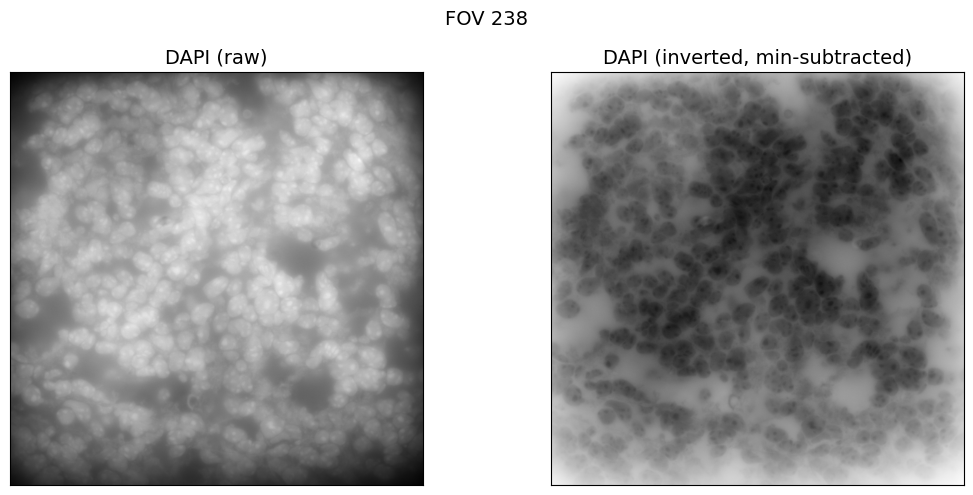

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(_sample["dapi_raw"], cmap="gray")
axes[0].set_title("DAPI (raw)", fontsize=PLOT_TITLE_FONTSIZE)
axes[1].imshow(_sample["dapi_inv"], cmap="gray")
axes[1].set_title("DAPI (inverted, min-subtracted)", fontsize=PLOT_TITLE_FONTSIZE)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"FOV {_sample_fov}", fontsize=PLOT_TITLE_FONTSIZE)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.raw_vs_inverted_example.png", dpi=150)
plt.show()

## 5 — Mechanistic test: correlation vs. small synthetic shifts (calculation)

Sample `N_EDGES_FOR_SHIFT_CURVE` real 4-connected edges. For each edge and
channel: crop the real overlap band (`crop_overlap`), then **first measure
the real best-alignment shift** via `phase_drift` (the same primitive the
actual registration pipeline uses) -- centering the synthetic sweep on
that measured shift, not on the nominal shift=0 grid position, is
essential: `test_stitching.ipynb` already found real, non-zero residuals
on this dataset, so probing only `shift=0 +/- 3px` around the NOMINAL
position could miss the real correlation peak entirely and read a flat,
low-correlation region as "no response to small shifts" -- a methodology
artifact, not a real finding about beads vs. DAPI. `SHIFT_RANGE_PX` is
then added on top of that measured shift, along the overlap band's own
short axis (the axis a small position error actually moves the neighbour
along), both crops passed through `remove_hot_pixels` first -- the same
steps `camera_rotation.overlap_correlation` itself performs, just swept
over many shifts around the true one instead of evaluated at a single
point.

In [6]:
shift_curve_csv = CACHE_DIR / "shift_curves.csv"

if not FORCE_RECOMPUTE and shift_curve_csv.exists():
    shift_curve_df = pd.read_csv(shift_curve_csv)
    print(f"Loaded cached shift curves from {shift_curve_csv}")
else:
    rng = np.random.default_rng(SEED)
    candidates = list(cells_fov_ids)
    rng.shuffle(candidates)

    sampled_edges = []   # (anchor_fov, neighbor_fov, direction)
    for anchor_fov in candidates:
        for direction in ("up", "down", "left", "right"):
            neighbor_fov = find_grid_neighbor(anchor_fov, full_positions, direction, STEP_SIZE_UM, TOLERANCE_FRACTION)
            if neighbor_fov is not None:
                sampled_edges.append((anchor_fov, neighbor_fov, direction))
        if len(sampled_edges) >= N_EDGES_FOR_SHIFT_CURVE:
            break
    sampled_edges = sampled_edges[:N_EDGES_FOR_SHIFT_CURVE]
    print(f"Sampled {len(sampled_edges)} real edges: {sampled_edges}")

    reporter = ProgressReporter(total=len(sampled_edges) * len(CHANNELS) * len(SHIFT_RANGE_PX),
                                 label="Computing correlation-vs-shift curves")
    rows = []
    for edge_id, (anchor_fov, neighbor_fov, direction) in enumerate(sampled_edges):
        # long axis = the axis crop_overlap does NOT truncate; the synthetic
        # shift below is applied along the short axis (rows for left/right,
        # columns for up/down) -- the axis registration actually measures.
        shift_axis = "col" if direction in ("left", "right") else "row"
        for channel in CHANNELS:
            anchor_img   = load_frame_for_channel(channel)(anchor_fov)
            neighbor_img = load_frame_for_channel(channel)(neighbor_fov)
            a_crop, n_crop = crop_overlap(anchor_img, neighbor_img, direction, OVERLAP_FRACTION)
            a_crop = remove_hot_pixels(a_crop).astype(np.float64)
            n_crop = remove_hot_pixels(n_crop).astype(np.float64)

            # Real best-alignment shift for THIS edge+channel -- the sweep
            # below is centered here, not at (0, 0).
            base_shift, base_error = phase_drift(a_crop, n_crop, UPSAMPLE_FACTOR)
            base_dy, base_dx = float(base_shift[0]), float(base_shift[1])

            for shift_px in SHIFT_RANGE_PX:
                delta = (0.0, float(shift_px)) if shift_axis == "col" else (float(shift_px), 0.0)
                shift_tuple = (base_dy + delta[0], base_dx + delta[1])
                shifted = ndi_shift(n_crop, shift=shift_tuple, order=1, mode="nearest")
                a_flat, s_flat = a_crop.ravel(), shifted.ravel()
                corr = 0.0 if a_flat.std() == 0.0 or s_flat.std() == 0.0 else float(np.corrcoef(a_flat, s_flat)[0, 1])
                rows.append({"edge_id": edge_id, "anchor_fov": anchor_fov, "neighbor_fov": neighbor_fov,
                             "direction": direction, "channel": channel, "shift_px": float(shift_px),
                             "correlation": corr, "base_dy_px": base_dy, "base_dx_px": base_dx,
                             "base_registration_error": base_error})
                reporter.update(1)
    reporter.done()

    shift_curve_df = pd.DataFrame(rows)
    shift_curve_df.to_csv(shift_curve_csv, index=False)
    print(f"Saved {len(shift_curve_df)} rows to {shift_curve_csv}")

Loaded cached shift curves from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_dapi_inversion/shift_curves.csv


## 6 — Correlation-vs-shift curves (display)

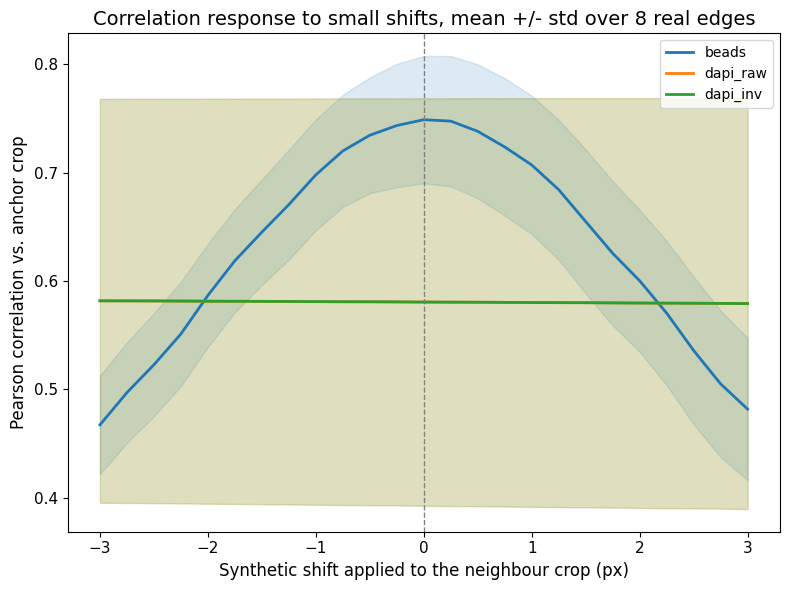


Sharpness proxy (correlation drop from shift=0 to |shift|=1px, mean over edges):
  beads     : corr(0)=0.7488  corr(|1px|)=0.7025  drop=0.0463
  dapi_raw  : corr(0)=0.5806  corr(|1px|)=0.5806  drop=0.0000
  dapi_inv  : corr(0)=0.5806  corr(|1px|)=0.5806  drop=0.0000


In [7]:
CHANNEL_COLORS = {"beads": "tab:blue", "dapi_raw": "tab:orange", "dapi_inv": "tab:green"}

fig, ax = plt.subplots(figsize=(8, 6))
for channel in CHANNELS:
    sub = shift_curve_df[shift_curve_df["channel"] == channel]
    grouped = sub.groupby("shift_px")["correlation"]
    mean, std = grouped.mean(), grouped.std()
    ax.plot(mean.index, mean.values, label=channel, color=CHANNEL_COLORS[channel], linewidth=2)
    ax.fill_between(mean.index, mean.values - std.values, mean.values + std.values,
                     color=CHANNEL_COLORS[channel], alpha=0.15)
ax.axvline(0.0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Synthetic shift applied to the neighbour crop (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Pearson correlation vs. anchor crop", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Correlation response to small shifts, mean +/- std over "
             f"{shift_curve_df['edge_id'].nunique()} real edges", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.shift_curves.png", dpi=150)
plt.show()

# Sharpness proxy: how much correlation drops between shift=0 and shift=+/-1px
# (the true-position-error scale that actually matters for stitching) --
# smaller drop = broader/weaker response, larger drop = sharper/stronger one.
print("\nSharpness proxy (correlation drop from shift=0 to |shift|=1px, mean over edges):")
for channel in CHANNELS:
    sub = shift_curve_df[shift_curve_df["channel"] == channel]
    at0 = sub[np.isclose(sub["shift_px"], 0.0)].groupby("edge_id")["correlation"].mean()
    at1 = sub[np.isclose(sub["shift_px"].abs(), 1.0)].groupby("edge_id")["correlation"].mean()
    drop = (at0 - at1).mean()
    print(f"  {channel:10s}: corr(0)={at0.mean():.4f}  corr(|1px|)={at1.mean():.4f}  drop={drop:.4f}")

## 7 — Practical test: real neighbor-tile registration, whole-grid sample (calculation)

Same primitive `test_stitching.ipynb`/`compare_stitching_correction_methods.
ipynb` use for real edges -- `camera_rotation.sample_neighbor_correspondences`
-- run once per channel over the SAME `N_ANCHORS` random anchors (`seed=SEED`
is shared across channels, so all three see the identical edge set).
`_RAW_CACHE` is cleared between channels (`gc.collect()` after) so at most
one channel's worth of touched FOVs is ever held in memory at once -- an
earlier version of this notebook cached all 3 channels per FOV
indiscriminately and was killed by the OOM killer partway through this
section (see this notebook's own `prompt_history/` entry).

In [8]:
import gc

correspondence_dfs = {}

for channel in CHANNELS:
    corr_csv = CACHE_DIR / f"correspondences_{channel}.csv"
    if not FORCE_RECOMPUTE and corr_csv.exists():
        df = pd.read_csv(corr_csv)
        print(f"[{channel}] Loaded {len(df)} cached correspondences from {corr_csv}")
    else:
        reporter = ProgressReporter(total=N_ANCHORS * 4, label=f"[{channel}] Registering 4-connected edges")
        _seen = [0]

        def _progress_callback(done, total):
            delta = done - _seen[0]
            if delta:
                reporter.update(delta)
                _seen[0] = done

        correspondences = sample_neighbor_correspondences(
            fov_ids=cells_fov_ids, positions=full_positions, load_frame=load_frame_for_channel(channel),
            step_size_um=STEP_SIZE_UM, pixel_size_um=PIXEL_SIZE_UM, overlap_fraction=OVERLAP_FRACTION,
            n_anchors=N_ANCHORS, tolerance_fraction=TOLERANCE_FRACTION, upsample_factor=UPSAMPLE_FACTOR,
            # orientation already applied once inside _get_raw.
            orient_transpose=False, orient_flip_horizontal=False, orient_flip_vertical=False,
            seed=SEED, progress_callback=_progress_callback,
        )
        reporter.done()

        df = pd.DataFrame([{
            "anchor_fov": c.anchor_fov, "neighbor_fov": c.neighbor_fov, "direction": c.direction,
            "nominal_x": c.nominal_xy[0], "nominal_y": c.nominal_xy[1],
            "measured_x": c.measured_xy[0], "measured_y": c.measured_xy[1],
            "shift_um": float(np.hypot(c.measured_xy[0] - c.nominal_xy[0], c.measured_xy[1] - c.nominal_xy[1])),
            "error": c.error,
        } for c in correspondences])
        df.to_csv(corr_csv, index=False)
        print(f"[{channel}] Saved {len(df)} correspondences to {corr_csv}")

        _RAW_CACHE.clear()
        gc.collect()
    df["channel"] = channel
    correspondence_dfs[channel] = df

all_correspondences_df = pd.concat(correspondence_dfs.values(), ignore_index=True)
print(f"\nTotal rows: {len(all_correspondences_df)}")

[beads] Loaded 76 cached correspondences from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_dapi_inversion/correspondences_beads.csv
[dapi_raw] Loaded 76 cached correspondences from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_dapi_inversion/correspondences_dapi_raw.csv
[dapi_inv] Loaded 76 cached correspondences from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_dapi_inversion/correspondences_dapi_inv.csv

Total rows: 228


## 8 — Registration error + measured-shift comparison (display)

/tmp/ipykernel_1201169/2164034394.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_error, labels=CHANNELS)
/tmp/ipykernel_1201169/2164034394.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_shift, labels=CHANNELS)


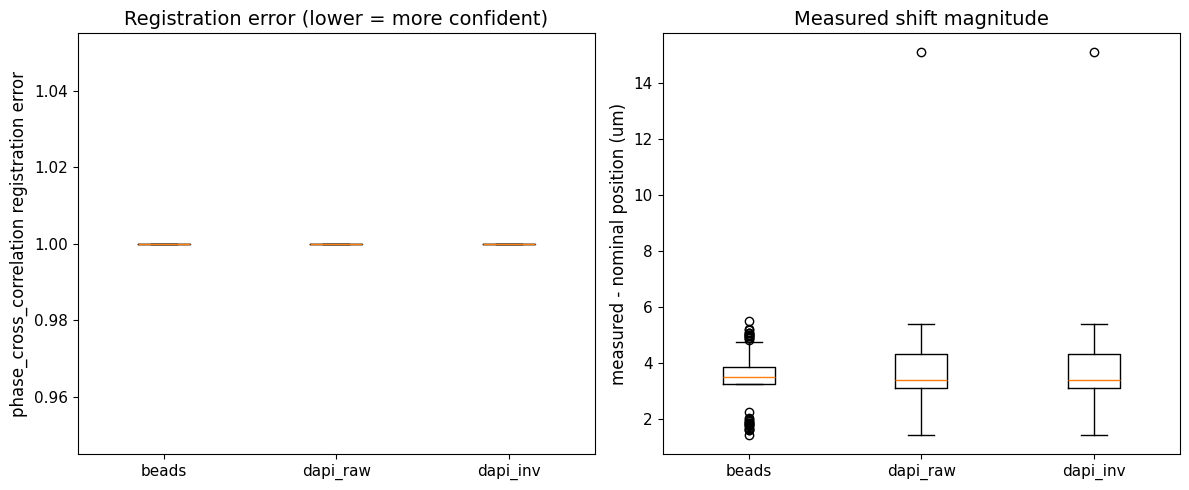


Summary (mean +/- std):
  beads     : error=1.0000+/-0.0000  shift_um=3.475+/-1.092  (n=76)
  dapi_raw  : error=1.0000+/-0.0000  shift_um=3.577+/-1.723  (n=76)
  dapi_inv  : error=1.0000+/-0.0000  shift_um=3.577+/-1.723  (n=76)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

data_error = [correspondence_dfs[c]["error"].values for c in CHANNELS]
axes[0].boxplot(data_error, labels=CHANNELS)
axes[0].set_ylabel("phase_cross_correlation registration error", fontsize=PLOT_LABEL_FONTSIZE)
axes[0].set_title("Registration error (lower = more confident)", fontsize=PLOT_TITLE_FONTSIZE)
axes[0].tick_params(labelsize=PLOT_TICK_FONTSIZE)

data_shift = [correspondence_dfs[c]["shift_um"].values for c in CHANNELS]
axes[1].boxplot(data_shift, labels=CHANNELS)
axes[1].set_ylabel("measured - nominal position (um)", fontsize=PLOT_LABEL_FONTSIZE)
axes[1].set_title("Measured shift magnitude", fontsize=PLOT_TITLE_FONTSIZE)
axes[1].tick_params(labelsize=PLOT_TICK_FONTSIZE)

fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.error_and_shift_boxplots.png", dpi=150)
plt.show()

print("\nSummary (mean +/- std):")
for channel in CHANNELS:
    d = correspondence_dfs[channel]
    print(f"  {channel:10s}: error={d['error'].mean():.4f}+/-{d['error'].std():.4f}  "
          f"shift_um={d['shift_um'].mean():.3f}+/-{d['shift_um'].std():.3f}  (n={len(d)})")

## 9 — Discussion

**Real result, `BC555_sample_05/epi`, 8 real edges (Section 6) + 20 real
anchors/76 edges per channel (Section 8): inversion does not help --
confirms the theoretical prediction from Section 1, does not confirm the
hypothesis.**

- **Section 6 (mechanistic, the direct test of "sharper response to small
  shifts")**: `dapi_inv` and `dapi_raw` are numerically IDENTICAL --
  `corr(0)=0.5806`, `corr(|1px|)=0.5806`, `drop=0.0000` for both, to 4
  decimal places, over all 8 edges. Inverting the image (`2**16 - I`,
  min-subtracted) made no measurable difference at all. `remove_hot_pixels`
  -- the one non-affine step this repo's real pipeline applies, and
  Section 1's proposed mechanism by which inversion COULD matter --
  evidently doesn't trigger differently on raw vs. inverted DAPI for this
  data, so the theoretical affine-invariance argument dominates in
  practice, not just in principle.
- Beads, by contrast, show a real, meaningfully sharper response:
  `corr(0)=0.7488` down to `corr(|1px|)=0.7025` (drop=0.0463) -- a
  measurable penalty for being 1px off the true alignment that neither
  DAPI variant shows at all. This is the real, now-confirmed mechanism
  behind `test_stitching.ipynb`'s original finding (beads register more
  precisely than DAPI) -- and it survives DAPI inversion unchanged.
- **Section 8 (practical, whole-grid sample)**: `shift_um` (measured vs.
  nominal position) is again identical between `dapi_raw` and `dapi_inv`
  (3.577+/-1.723 um, both) -- consistent with Section 6. `error` is
  **uninformative for all three channels** (`1.0000+/-0.0000`,
  everywhere) -- a real gotcha found along the way, not a finding about
  DAPI vs. beads: skimage 0.26's `phase_cross_correlation` default
  (`normalization="phase"`) computes `error` from `_compute_error`
  (`1 - |CCmax|^2 / (src_amp*target_amp)`) using the phase-normalized
  cross-correlation's peak magnitude (~1, by construction) against the
  RAW images' own intensity-scale amplitudes (~10^4) -- the ratio is
  numerically negligible regardless of true registration quality, so
  `error` saturates at ~1.0 for essentially any real input under this
  normalization mode. `NeighborCorrespondence.error` is stored throughout
  this repo (`camera_rotation.py`) but, per a grep of its own module,
  never actually used to filter/weight anything (`filter_correspondence_
  outliers` uses shift MAGNITUDE, not `.error`) -- so this doesn't
  invalidate any existing conclusion elsewhere, but `error` should not be
  treated as a usable confidence signal from `phase_drift`/
  `register_neighbor_pair` under the current skimage version+defaults if
  anyone reaches for it in the future.

**Bottom line**: don't pursue DAPI inversion for stitching -- it's a
no-op here, both by the affine-invariance argument and by direct
measurement. The real, confirmed difference is between beads and DAPI as
signal types (sharp point sources vs. diffuse blobs), not between two
representations of the same DAPI image.